**Fundamentos de Data Science**

Analizando la Rotación de Clientes en Telecomunicaciones

**1. Limpieza de datos con Python:**

1.1. Identificar y solucionar cualquier valor duplicado.

1.2. Asegurarse de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.

1.3. Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).

1.4. Identificar y solucionar cualquier valor faltante en el dataset. Rellenar los valores faltantes con un marcador adecuado para el tipo de dato.

1.5. Identificar y solucionar cualquier punto de dato inapropiado o inusual (ejemplo: la edad no puede ser 325).

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [115]:
# ¿Cuántas filas y columnas tiene?
print(f"Shape: {df.shape}")

Shape: (7043, 21)


In [116]:
# Primeras filas (vista rápida)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [117]:
# Tipos de datos y valores no nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [118]:
# Estadísticas descriptivas de columnas numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [119]:
# Últimas 5 filas
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [120]:
# ¿Cuántos nulos hay en cada columna?
nulos = df.isnull().sum()
print("Nulos por columna:")
print(nulos)
print()

Nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64



In [121]:
# 1.1. Identificar y solucionar cualquier valor duplicado
duplicados = df.duplicated().sum()
print("Cantidad de filas duplicadas:")
print(duplicados)

Cantidad de filas duplicadas:
0


Podemos observar que no se encuentran valores duplicados.

In [122]:
# 1.2. Asegurarse de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [124]:
# Convertir TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [126]:
tipos_correctos = {
    'customerID': 'string',
    'gender': 'string',
    'SeniorCitizen': 'Int64',
    'Partner': 'string',
    'Dependents': 'string',
    'tenure': 'Int64',
    'PhoneService': 'string',
    'MultipleLines': 'string',
    'InternetService': 'string',
    'OnlineSecurity': 'string',
    'DeviceProtection': 'string',
    'TechSupport': 'string',
    'StreamingTV': 'string',
    'StreamingMovies': 'string',
    'Contract': 'string',
    'PaperlessBilling': 'string',
    'PaymentMethod': 'string',
    'MonthlyCharges': 'float64',
    'TotalCharges': 'float64',
    'Churn': 'string',
    }
df = df.astype(tipos_correctos)
print(df.dtypes)

customerID          string[python]
gender              string[python]
SeniorCitizen                Int64
Partner             string[python]
Dependents          string[python]
tenure                       Int64
PhoneService        string[python]
MultipleLines       string[python]
InternetService     string[python]
OnlineSecurity      string[python]
OnlineBackup                object
DeviceProtection    string[python]
TechSupport         string[python]
StreamingTV         string[python]
StreamingMovies     string[python]
Contract            string[python]
PaperlessBilling    string[python]
PaymentMethod       string[python]
MonthlyCharges             float64
TotalCharges               float64
Churn               string[python]
dtype: object


Se revisa como está considerada cada columna si corresponde a texto, numero entero y con decimales para poder generar futuros gráficos.

In [127]:
# 1.3. Identificar y solucionar cualquier inconsistencia en los valores categóricos.
columnas_categoricas = df.select_dtypes(include=['object', 'string']).columns

# Revisar valores únicos
for col in columnas_categoricas:
    print(f"\nColumna: {col}")
    print(df[col].unique())



Columna: customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: string

Columna: gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: string

Columna: Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: string

Columna: Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: string

Columna: PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: string

Columna: MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: string

Columna: InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: string

Columna: OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: string

Columna: OnlineBackup
['Yes' 'No' 'No internet service']

C

In [128]:
# 1.4. Identificar y solucionar cualquier valor faltante en el dataset.
# Rellenar los valores faltantes con un marcador adecuado para el tipo de dato.

# Contar valores nulos por columna
nulos = df.isnull().sum()

print("Valores faltantes por columna:")
print(nulos)

Valores faltantes por columna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [129]:
# 1.5. Identificar datos inusuales

# Revisar estadísticas generales
print(df.describe())

# Verificar valores de SeniorCitizen
print("\nValores únicos de SeniorCitizen:")
print(df['SeniorCitizen'].unique())

# Convertir TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)


       SeniorCitizen     tenure  MonthlyCharges  TotalCharges
count         7043.0     7043.0     7043.000000   7032.000000
mean        0.162147  32.371149       64.761692   2283.300441
std         0.368612  24.559481       30.090047   2266.771362
min              0.0        0.0       18.250000     18.800000
25%              0.0        9.0       35.500000    401.450000
50%              0.0       29.0       70.350000   1397.475000
75%              0.0       55.0       89.850000   3794.737500
max              1.0       72.0      118.750000   8684.800000

Valores únicos de SeniorCitizen:
<IntegerArray>
[0, 1]
Length: 2, dtype: Int64


Al visualizar las columnas se puede observar que la columna TotalCharges tiene 11 clientes menos.

In [130]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges']]

,tenure,MonthlyCharges
488,0,52.55
753,0,20.25
936,0,80.85
1082,0,25.75
1340,0,56.05
3331,0,19.85
3826,0,25.35
4380,0,20.00
5218,0,19.70
6670,0,73.35


Con esto se podría concluir que los 11 faltantes en columna TotalCharges son clientes nuevos.

**2. Exploración de datos con Python:**

2.1. Crear dos tipos diferentes de visualizaciones exploratorias univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

2.2. Crear dos tipos diferentes de visualizaciones exploratorias multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.


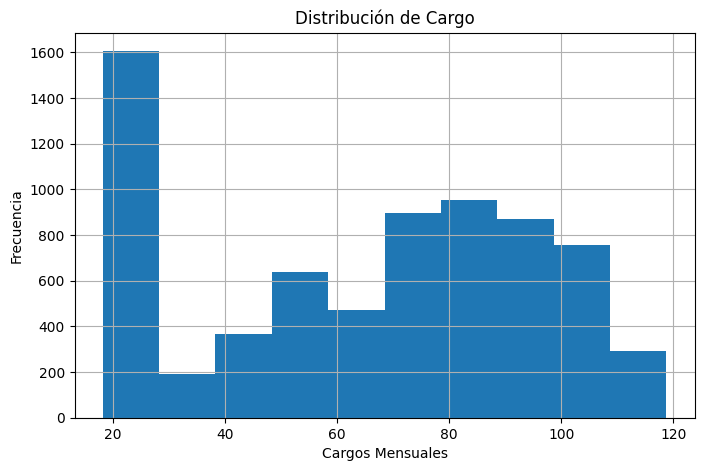

La mayoria de los clientes presenta cargos mensuales


In [131]:
# 2.1. Crear dos tipos diferentes de visualizaciones exploratorias univariadas.
# Cada visualización debe incluir una breve interpretación dentro del archivo de código.

# 2.1.1. Histograma de MonthlyCharges

df['MonthlyCharges'].hist(figsize=(8,5))

plt.title('Distribución de Cargo')
plt.xlabel('Cargos Mensuales')
plt.ylabel('Frecuencia')

plt.show()

print ('La mayoria de los clientes presenta cargos mensuales')

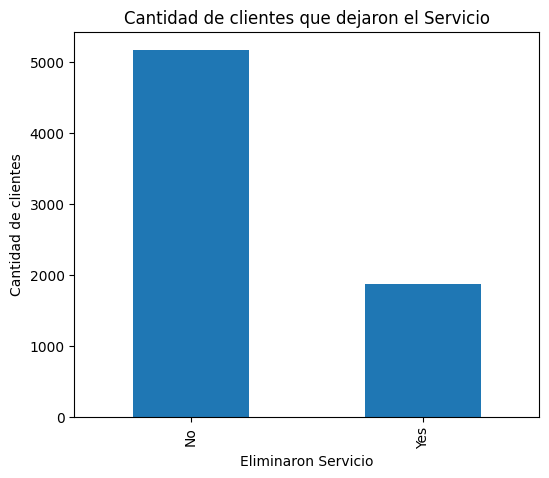

La mayoria de los clientes no ha eliminado el servicio en el ultimo mes


In [133]:
# 2.1.2. Cantidad de clientes por Churn

df['Churn'].value_counts().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Cantidad de clientes que dejaron el Servicio')
plt.xlabel('Eliminaron Servicio')
plt.ylabel('Cantidad de clientes')

plt.show()

print ('La mayoria de los clientes no ha eliminado el servicio en el ultimo mes')

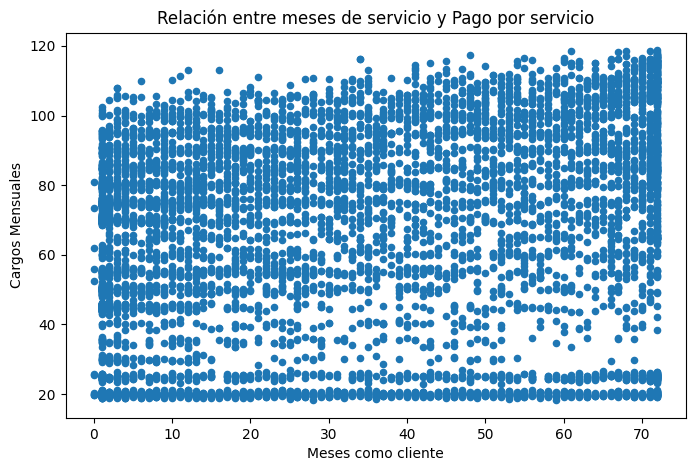

No se ve influencia entre meses de servivio y pago por servicios


In [134]:
# 2.2. Crear dos tipos diferentes de visualizaciones exploratorias multivariadas.
# Cada visualización debe incluir una breve interpretación dentro del archivo de código.

# 2.2.1. Relación entre tenure y MonthlyCharges
df.plot(
    kind='scatter',
    x='tenure',
    y='MonthlyCharges',
    figsize=(8,5)
)

plt.title('Relación entre meses de servicio y Pago por servicio')
plt.xlabel('Meses como cliente')
plt.ylabel('Cargos Mensuales')

plt.show()
print ('No se ve influencia entre meses de servivio y pago por servicios')

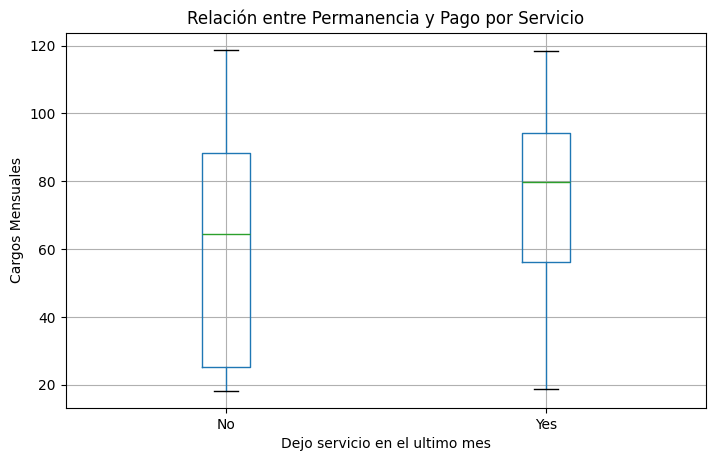

No se ve influencia entre permanencia y pago por servicios.
Pero se observa que los que dejaron el servicio el ultimo mes, tuvieron un pago por servicio mayor.


In [135]:
# 2.2.2. Comparar MonthlyCharges según Churn

df.boxplot(
    column='MonthlyCharges',
    by='Churn',
    figsize=(8,5)
)

plt.title('Relación entre Permanencia y Pago por Servicio')
plt.suptitle('')

plt.xlabel('Dejo servicio en el ultimo mes')
plt.ylabel('Cargos Mensuales')

plt.show()
print ('No se ve influencia entre permanencia y pago por servicios.')
print ('Pero se observa que los que dejaron el servicio el ultimo mes, tuvieron un pago por servicio mayor.')

**Resumen final del analisis**

Limpieza realizada:

No se encontraron nulos, ni duplicados.

Se reviso diccionario para evitar conflictos con los futuros graficos.

Se reviso que no hubieran datos erroneos o incosistencia.

Mediante visualizaciones univariadas y multivariadas fue posible identificar la distribución de los cargos mensuales y analizar relaciones entre variables relevantes, como la permanencia del cliente y los cargos del servicio. Este proceso permitió comprender mejor el comportamiento de los clientes y preparar correctamente los datos para futuros análisis y modelos predictivos.

Nota: Se utilizo ChatGpt para revisar errores que se hayan generado en la aplicacion de codigos.

